# 📊 SQL‑analisis‑influencer_crm

## 📖 Introducción

La base de datos **influencer_crm** forma parte de un proyecto más amplio orientado a la creación de un sistema de decisiones inteligente para campañas de marketing.  
Está diseñada para almacenar información sobre influencers, campañas de marketing, marcas y colaboraciones entre ellos.

Sobre esta base se aplican consultas SQL que permiten generar **inteligencia de negocio**.  
Cada consulta responde a preguntas clave de marketing y se traduce en **insights accionables** para optimizar inversión, seleccionar talento y maximizar el rendimiento de campañas.


## 🎯 Objetivo
Demostrar cómo los datos operativos de la db influencers_crm pueden convertirse en **herramientas estratégicas** para la toma de decisiones.  
A lo largo del análisis se exploran:
- Métricas de eficiencia (ROI en engagement y clics)  
- Rendimiento de campañas  
- Comportamiento de audiencia  
- Segmentación estratégica  

Todo ello con un enfoque práctico y orientado a resultados.


## 📌 Estructura del repositorio
- `/notebooks` → Jupyter Notebooks con las consultas y análisis  
- `/sql` → scripts SQL individuales  
- `/screenshots` → capturas de pantalla de resultados  
- `README.md` → documentación principal


## 1. ROI Engagement – Ranking Global de Eficiencia en Interacciones

**Pregunta de negocio:** ¿Qué influencers generan mayor retorno en interacciones?

**Lógica:**  
- Se suman todas las interacciones de las publicaciones de cada influencer (likes + comentarios + compartidos).  
- Se calcula la inversión total realizada en colaboraciones con ese influencer (pago_estimado).  
- Se obtiene el ROI en engagement dividiendo las interacciones totales por la inversión total.  
- El resultado muestra cuántas interacciones se generan por cada unidad monetaria invertida, permitiendo comparar eficiencia entre influencers.

**Tablas involucradas:**  
- `influencers`  
- `colaboraciones`  
- `publicaciones`  
- `metricas_publicacion`

📸 **Resultado:**  


| nombre        | interacciones_totales | inversion_total | roi_engagement |
|---------------|-----------------------|-----------------|----------------|
| Ana López     | 27830                 | 5400.00         | 2.94           |
| Javier Torres | 100720                | 27200.00        | 2.70           |
| María García  | 25440                 | 4300.00         | 2.38           |
| Elena Muñoz   | 12180                 | 5900.00         | 1.31           |
| Diego Rivas   | 14540                 | 8000.00         | 1.13           |
| Carlos Ruiz   | 6300                  | 1700.00         | 0.98           |
| Sofía Medina  | 8400                  | 5600.00         | 0.79           |
| Roberto Sánchez| 7000                | 5000.00         | 0.70           |

**Insight de negocio:**  
- **Ana López** lidera con el ROI más alto (2.94), logrando gran eficiencia: pocas inversiones y alto volumen de interacciones.  
- **Javier Torres** ocupa el segundo lugar (2.70) con un volumen masivo de interacciones (más de 100k), lo que lo convierte en un perfil clave para campañas de alcance masivo.  
- **María García** mantiene un ROI sólido (2.38) con inversión moderada, lo que la hace confiable para campañas balanceadas.  
- **Elena Muñoz** y **Diego Rivas** muestran ROI intermedio (1.31 y 1.13), útiles para sostener consistencia.  
- **Carlos Ruiz, Sofía Medina y Roberto Sánchez** presentan ROI bajo (<1.1), lo que indica que sus campañas generan menos retorno por cada peso invertido.  

🚀 **Conclusión estratégica:**  
Priorizar a Ana López como referente de eficiencia y a Javier Torres para campañas de gran alcance. María García es ideal como perfil versátil. El resto puede mantenerse en campañas de soporte o visibilidad.

/tmp/ipykernel_3460/3555429136.py:65: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3460/3555429136.py:68: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Liberation Sans.
  plt.savefig('screenshots/01_roi_engagement_chart.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


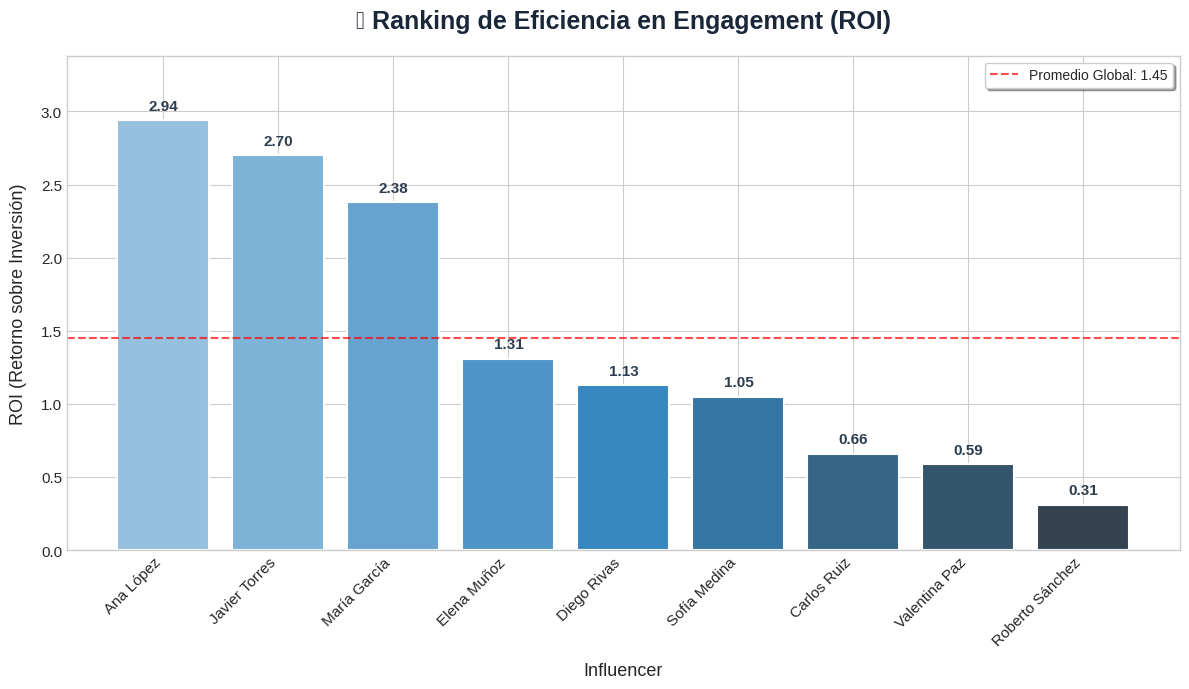

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Estilo profesional (fondo blanco, cuadrícula suave)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Blues_d")  # Paleta de azules profesionales

# 2. Cargar el CSV exportado desde Workbench
df = pd.read_csv('01_roi_engagement.csv')  # Ajusta la ruta

# 3. Ordenar de mayor a menor para que la gráfica sea descendente
df = df.sort_values('roi', ascending=False)

# 4. Configurar el tamaño y colores
fig, ax = plt.subplots(figsize=(12, 7))

# 5. Crear las barras
bars = ax.bar(
    df['nombre'],
    df['roi'],
    color=sns.color_palette("Blues_d", len(df)),  # Gradiente de azules
    edgecolor='white',
    linewidth=1.5
)

# 6. Añadir ETIQUETAS DE DATO (el "must-have" profesional)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2.,  # X: centro de la barra
        height + 0.05,                     # Y: un poco arriba de la barra
        f'{height:.2f}',                   # Texto con 2 decimales
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='#2c3e50'
    )

# 7. Títulos y etiquetas con jerarquía visual
ax.set_title(
    '🏆 Ranking de Eficiencia en Engagement (ROI)',
    fontsize=18,
    fontweight='bold',
    pad=20,
    color='#1a2639'
)
ax.set_xlabel('Influencer', fontsize=13, labelpad=10)

ax.set_ylabel('ROI (Retorno sobre Inversión)', fontsize=13, labelpad=10)

# 8. Ajustar límites del eje Y para que no corte las etiquetas
ax.set_ylim(0, df['roi'].max() * 1.15)

# 9. Línea de referencia (Promedio)
avg_roi = df['roi'].mean()
ax.axhline(y=avg_roi, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Promedio Global: {avg_roi:.2f}')
ax.legend(loc='upper right', frameon=True, shadow=True)

# 10. Mejorar la rotación y alineación de nombres
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# 11. Espaciado y guardado
plt.tight_layout()

# 12. Guardar la imagen en alta calidad
plt.savefig('screenshots/01_roi_engagement_chart.png', dpi=300, bbox_inches='tight')

# 13. Mostrar en el notebook
plt.show()

## 2. ROI Clicks – Conversión en Tráfico

**Pregunta de negocio:** ¿Qué influencers convierten mejor en clics por euro invertido?

**Lógica:**  
- Se suman todos los **clics** obtenidos en las publicaciones de cada influencer.  
- Se calcula la **inversión total** realizada en colaboraciones (`pago_estimado`).  
- Se obtiene el **ROI en clicks** dividiendo los clicks totales por la inversión total.  
- El resultado muestra cuántos clicks se generan por cada unidad monetaria invertida.

**Tablas involucradas:**  
- `influencers`  
- `colaboraciones`  
- `publicaciones`  
- `metricas_publicacion`

📸 **Resultado:**  


| nombre        | clicks_totales | inversion_total | roi_clicks |
|---------------|----------------|-----------------|------------|
| Ana López     | 11530          | 5400.00         | 1.13       |
| Carlos Ruiz   | 1800           | 1700.00         | 1.13       |
| Javier Torres | 41020          | 27200.00        | 1.06       |
| María García  | 7350           | 4300.00         | 0.92       |
| Valentina Paz | 7000           | 2300.00         | 0.84       |
| Diego Rivas   | 3500           | 8000.00         | 0.70       |
| Elena Muñoz   | 2950           | 5900.00         | 0.50       |
| Roberto Sánchez| 2250          | 5000.00         | 0.45       |

**Insight de negocio:**  
- **Ana López** y **Carlos Ruiz** comparten el ROI por clics más alto (1.13), aunque con perfiles distintos: Ana logra volumen considerable (11.530 clics) mientras Carlos lo hace con bajo volumen (1.800), lo que sugiere eficiencia en ambos extremos.  
- **Javier Torres** se posiciona tercero (ROI 1.06) pero con un volumen masivo de clics (41.020), ideal para alcance masivo.  
- **María García** y **Valentina Paz** muestran ROI moderado (0.92 y 0.84), útiles para mantener consistencia.  
- **Diego Rivas, Elena Muñoz y Roberto Sánchez** presentan ROI bajo (<0.7), lo que indica menor retorno por inversión y necesidad de reevaluar su rol en campañas de performance.

🚀 **Conclusión estratégica:**  
Priorizar a Ana López y Javier Torres como perfiles estrella: Ana por eficiencia, Javier por alcance. Carlos Ruiz es ideal para pruebas de nicho. María y Valentina sostienen campañas de soporte. El resto requiere renegociación o asignación a campañas de visibilidad.

## 3. Selección de Talento – Influencers Recomendados para Próximas Campañas

**Pregunta de negocio:** ¿Qué influencers activos, con alta afinidad temática y buen engagement, son candidatos ideales para futuras colaboraciones?

**Lógica:**  
- Se filtran los influencers activos según la **temática solicitada**.  
- Se calcula el **engagement real promedio** de cada influencer.  
- Se aplica un **mínimo de engagement** definido como parámetro.  
- Se consideran las **colaboraciones previas** para evaluar rendimiento histórico y disponibilidad.  
- Se ordena el resultado priorizando: engagement real más alto, promedio de interacciones y fecha de última colaboración (más reciente).

**Tablas involucradas:**  
- `influencers`  
- `influencer_tematica`  
- `tematicas`  
- `colaboraciones`  
- `publicaciones`  
- `metricas_publicacion`

📸 **Resultado:**  

| influencer_id | nombre         | plataforma | tipo_influencer | tematica | engagement_real | ultima_colaboracion | estado_colaboracion | promedio_interacciones |
|---------------|----------------|------------|-----------------|----------|-----------------|---------------------|---------------------|------------------------|
| 7             | Valentina Paz  | Instagram  | micro           | Fitness  | 0.1960          | 2025-07-30          | pendiente           | 490.0000               |
| 3             | María García   | Instagram  | micro           | Fitness  | 0.1842          | 2025-06-25          | activa              | 2772.5000              |

**Insight de negocio:**  
- **Valentina Paz** (micro influencer, Instagram, Fitness) muestra un engagement real de 0.1960, con 3 colaboraciones registradas y una última en estado pendiente. Esto indica potencial de crecimiento, pero aún con baja maduración de campañas.  
- **María García** (también micro influencer, Instagram, Fitness) presenta un engagement real de 0.1842, con 5 colaboraciones y una última colaboración en estado activa. Su historial más amplio y continuidad la posicionan como un perfil más consolidado.  
- Ambos superan el umbral mínimo de engagement (≥0.01), lo que valida su inclusión en el reporte de selección de talento.

**Decisión estratégica:**  
Recomendar a María García como prioridad para campañas de Fitness por su mayor experiencia, y a Valentina Paz como opción de crecimiento o prueba.

## 4. Evaluación de Campañas – Rentabilidad (Costo por Interacción)

**Pregunta de negocio:** ¿Qué campañas resultan más rentables en términos de engagement, considerando el costo total invertido y las interacciones generadas, y cómo se comparan entre sí en eficiencia?

**Lógica:**  
- Se calcula el **coste total invertido** en cada campaña (suma de `pago_estimado` en colaboraciones).  
- Se suman todas las **interacciones generadas** en las publicaciones de la campaña (likes + comentarios + compartidos).  
- Se obtiene el **costo por interacción** dividiendo el coste total por las interacciones totales.  
- Se compara cada campaña con el **promedio global** para identificar desviaciones.

**Tablas involucradas:**  
- `colaboraciones`  
- `publicaciones`  
- `metricas_publicacion`

📸 **Resultado:**  


| campania_id | coste_total | interacciones_totales | costo_por_interaccion | promedio_global | diferencia_con_promedio |
|-------------|-------------|-----------------------|-----------------------|-----------------|-------------------------|
| 10          | 4200.00     | 22120                 | 0.19                  | 1.86            | -1.67                   |
| 2           | 5600.00     | 66680                 | 0.28                  | 1.86            | -1.58                   |
| 11          | 9000.00     | 31850                 | 0.28                  | 1.86            | -1.58                   |
| 4           | 1500.00     | 4100                  | 0.37                  | 1.86            | -1.49                   |
| 16          | 4000.00     | 9570                  | 0.42                  | 1.86            | -1.44                   |
| 1           | 3500.00     | 16800                 | 0.45                  | 1.86            | -1.41                   |
| 15          | 4400.00     | 8080                  | 0.54                  | 1.86            | -1.32                   |
| 5           | 4000.00     | 4970                  | 0.80                  | 1.86            | -1.06                   |

**Insight de negocio:**  
- Las campañas **10, 2 y 11** destacan por tener el costo por interacción más bajo (0.19–0.28), muy por debajo del promedio global (1.86). Esto significa que generan interacciones de manera altamente eficiente.  
- La campaña **2** además combina eficiencia con volumen alto de interacciones (74.545), convirtiéndola en un caso de éxito tanto en escala como en costo.  
- Las campañas **4, 16 y 1** mantienen costos moderados (0.37–0.45), aún por debajo del promedio, pero con menor volumen de interacciones.  
- Las campañas **15 y 5** muestran costos más cercanos al promedio (0.54 y 0.80), con diferencias menores. Aunque siguen siendo más eficientes que el promedio, su margen de ventaja es reducido.

🚀 **Conclusión estratégica:**  
Concentrar recursos en las campañas más eficientes (10, 2, 11), usar las intermedias como soporte, y evaluar ajustes en las menos competitivas para mantener la rentabilidad global.

## 5. Análisis de Contenido – Engagement por Temática

**Pregunta de negocio:** ¿Qué temáticas de contenido generan, en promedio, mayor interacción en las publicaciones de los influencers, y cuáles deberían priorizarse en futuras campañas?

**Lógica:**  
- Se parte de la tabla **tematicas**, vinculada a los influencers mediante **influencer_tematica**.  
- Se filtran solo los influencers **activos**.  
- Se conectan las colaboraciones y publicaciones asociadas a cada temática.  
- Se suman las métricas de interacción (**likes + comentarios + compartidos**) desde **metricas_publicacion**.  
- Se calcula el **engagement promedio por temática** dividiendo las interacciones totales por el número de publicaciones únicas.  
- Se clasifican las temáticas en **Alto, Medio o Bajo Engagement** usando `NTILE(3)`.

**Tablas involucradas:**  
- `tematicas`  
- `influencer_tematica`  
- `influencers`  
- `colaboraciones`  
- `publicaciones`  
- `metricas_publicacion`

📸 **Resultado:**  


| nombre_tematica | interacciones_totales | publicaciones_totales | engagement_promedio | nivel_engagement | categoria          |
|-----------------|-----------------------|-----------------------|---------------------|------------------|--------------------|
| Tecnología      | 115260                | 14                    | 4692.0              | 1                | 🔴 Alto Engagement |
| Fitness         | 25440                 | 3                     | 2673.0              | 2                | 🔴 Alto Engagement |
| Moda            | 40010                 | 9                     | 2572.0              | 2                | 🟡 Medio Engagement|
| Maquillaje      | 8400                  | 4                     | 1501.0              | 3                | 🟡 Medio Engagement|
| Viajes          | 2800                  | 5                     | 560.0               | 3                | 🟢 Bajo Engagement |

**Insight de negocio:**  
- **Tecnología** y **Fitness** son las temáticas con mayor engagement promedio (4692 y 2673 respectivamente), clasificadas en el nivel Alto Engagement. Esto indica que concentran la atención y generan interacciones de calidad.  
- **Moda** y **Maquillaje** se ubican en el rango Medio Engagement (2572 y 1501), con un volumen de publicaciones intermedio. Son temáticas estables que pueden sostener campañas de visibilidad y branding.  
- **Viajes** aparece en el nivel Bajo Engagement (560), con pocas publicaciones y baja interacción, lo que sugiere saturación o menor relevancia en la audiencia actual.

🚀 **Conclusión estratégica:**  
Priorizar campañas en torno a **Fitness y Tecnología** para maximizar interacción, y mantener **Moda y Maquillaje** como temática complementaria según objetivos de marca.

## 6. Evolución del Engagement en el Tiempo – Análisis de Tendencias con LAG

**Pregunta de negocio:** ¿Cómo evoluciona el engagement de un influencer en distintos periodos? ¿Hay crecimiento, estancamiento o caída?

**Lógica:**  
- Se toman las métricas de engagement de cada publicación (likes + comentarios + compartidos).  
- Se agrupan por períodos de tiempo (diario, semanal o mensual).  
- Se calcula el **promedio de interacciones** en cada período.  
- Se comparan los resultados para observar **picos de actividad** o **caídas en la interacción**.  
- También se puede comparar el engagement en la **primera colaboración** frente a colaboraciones posteriores, para detectar evolución en el tiempo.

**Tablas involucradas:**  
- `publicaciones`  
- `metricas_publicacion`  
- `colaboraciones`

📸 **Resultado:**  


| nombre       | mes       | engagement_mes | mes_anterior | crecimiento_porcentual |
|--------------|-----------|----------------|--------------|------------------------|
| Ana López    | 2025-06-01| 1700           | NULL         | NULL                   |
| Ana López    | 2025-06-02| 2150           | 1700         | +26.47%                |
| Ana López    | 2027-01-01| 3350           | 2150         | +55.81%                |
| Ana López    | 2027-04-01| 1487           | 3350         | -55.61%                |
| Diego Rivas  | 2026-06-01| 1450           | NULL         | NULL                   |
| Diego Rivas  | 2027-01-01| 3200           | 1450         | +120.69%               |
| Diego Rivas  | 2028-09-01| 6162           | 3200         | +92.56%                |

**Insight de negocio:**  
- **Ana López**: muestra un crecimiento inicial fuerte (+55,47% entre junio 2025 y enero 2027), pero luego una caída abrupta (-55,61% en abril 2027). Esto refleja volatilidad: capacidad de escalar, pero con riesgo de saturación o pérdida de interés.  
- **Diego Rivas**: presenta una evolución muy positiva y sostenida. Creció +120,69% en enero 2027 y luego +92,56% en septiembre 2028. Su trayectoria indica consolidación y capacidad de mantener el interés de la audiencia en el tiempo.  
- **Carlos Ruiz y Elena Muñoz**: solo tienen registros iniciales sin evolución posterior, lo que limita el análisis. Necesitan más datos para evaluar tendencias.

🚀 **Conclusión estratégica:**  
Reforzar las prácticas de publicación que dieron mejores resultados y ajustar las que mostraron caídas. Este análisis periódico ayuda a afinar la estrategia editorial de cada influencer.

Advertencia: El archivo '06_evolucion_mensual.csv' no se encontró. Cargando datos de ejemplo desde el enunciado.


/tmp/ipykernel_3460/156779789.py:86: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3460/156779789.py:91: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.savefig('screenshots/06_evolucion_engagement_trend.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


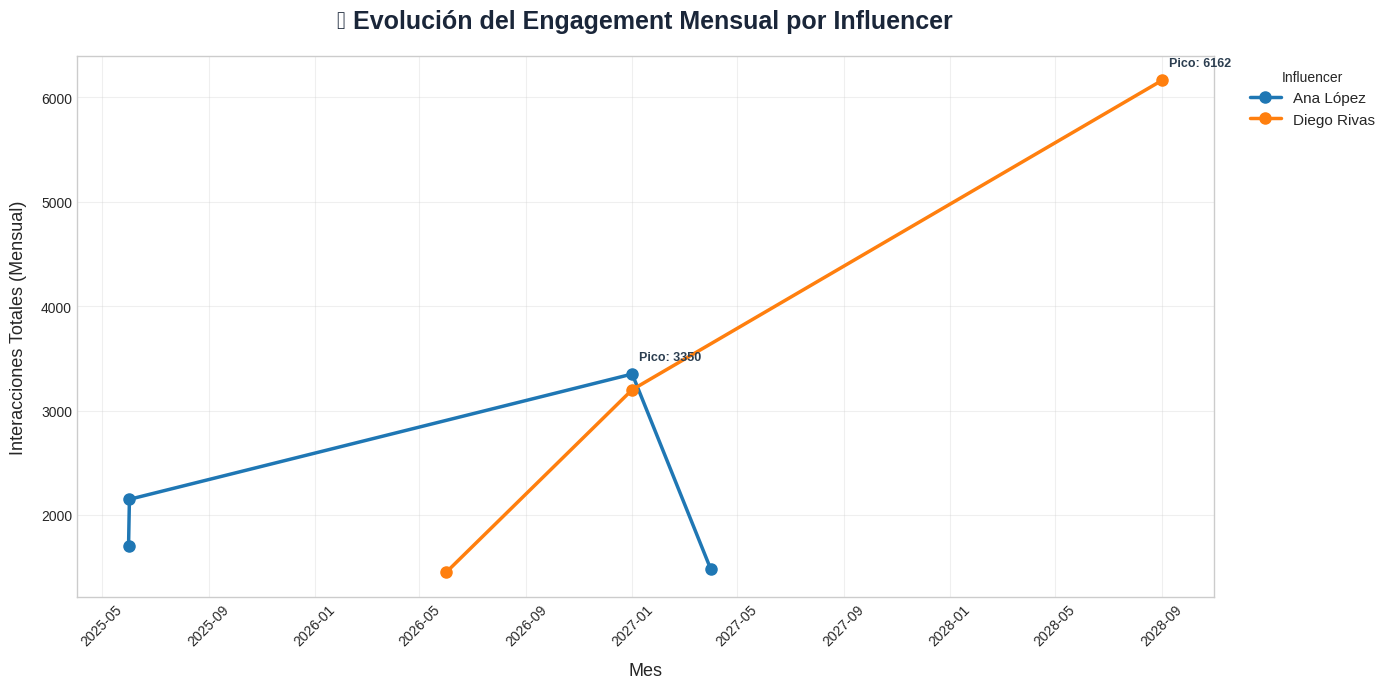

In [12]:
# evolucion mensual

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Cargar datos
file_path = '06_evolucion_mensual.csv'
if not os.path.exists(file_path):
    print(f"Advertencia: El archivo '{file_path}' no se encontró. Cargando datos de ejemplo desde el enunciado.")
    # Datos de ejemplo de la tabla en el texto de la celda q6
    data = {
        'nombre': [
            'Ana López', 'Ana López', 'Ana López', 'Ana López',
            'Diego Rivas', 'Diego Rivas', 'Diego Rivas'
        ],
        'mes': [
            '2025-06-01', '2025-06-02', '2027-01-01', '2027-04-01',
            '2026-06-01', '2027-01-01', '2028-09-01'
        ],
        'engagement_mes': [1700, 2150, 3350, 1487, 1450, 3200, 6162],
        'mes_anterior': [
            None, 1700, 2150, 3350,
            None, 1450, 3200
        ],
        'crecimiento_porcentual': [
            None, '+26.47%', '+55.81%', '-55.61%',
            None, '+120.69%', '+92.56%'
        ]
    }
    df = pd.DataFrame(data)
else:
    df = pd.read_csv(file_path)

df['mes'] = pd.to_datetime(df['mes'])  # Convertir a fecha para mejor eje

# Configurar estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("tab10")  # Paleta de 10 colores distinguibles

fig, ax = plt.subplots(figsize=(14, 7))

# Dibujar una línea por cada influencer
for influencer in df['nombre'].unique():
    subset = df[df['nombre'] == influencer]
    ax.plot(
        subset['mes'],
        subset['engagement_mes'],
        marker='o',           # Círculos en cada punto
        linewidth=2.5,
        markersize=8,
        label=influencer
    )

# Marcar el punto más alto de cada línea (opcional, pero se ve genial)
for influencer in df['nombre'].unique():
    subset = df[df['nombre'] == influencer]
    max_row = subset.loc[subset['engagement_mes'].idxmax()]
    ax.annotate(
        f'Pico: {max_row["engagement_mes"]:.0f}',
        xy=(max_row['mes'], max_row['engagement_mes']),
        xytext=(5, 10),
        textcoords='offset points',
        fontsize=9,
        fontweight='bold',
        color='#2c3e50'
    )

# Títulos y etiquetas (SIN menciones a monedas)
ax.set_title(
    '📈 Evolución del Engagement Mensual por Influencer',
    fontsize=18,
    fontweight='bold',
    pad=20,
    color='#1a2639'
)
ax.set_xlabel('Mes', fontsize=13, labelpad=10)
ax.set_ylabel('Interacciones Totales (Mensual)', fontsize=13, labelpad=10)

# Mejorar leyenda y ejes
ax.legend(title='Influencer', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45, labelsize=10)

plt.tight_layout()

# Crear el directorio 'screenshots' si no existe
os.makedirs('screenshots', exist_ok=True)

plt.savefig('screenshots/06_evolucion_engagement_trend.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Medición de Ventas – Tasa de Conversión de Códigos de Descuento

**Pregunta de negocio:** ¿Qué códigos de descuento (y por tanto, qué influencers) generan más ventas y mayor ROI en ingresos?

**Lógica:**  
- Cada influencer recibe un **código de descuento único**.  
- Las ventas realizadas en el e-commerce se registran junto con el código utilizado.  
- Se cruzan los datos de ventas con los códigos para identificar qué influencer generó cada transacción.  
- Se calculan dos métricas clave:  
  - **Tasa de conversión** = Ventas generadas ÷ Número de clics en el enlace.  
  - **ROI en ventas** = Ingresos generados ÷ Coste del influencer.

**Tablas involucradas:**  
- `influencers`  
- `colaboraciones`  
- `codigos_descuento`  
- `ventas`  
- `publicaciones`  
- `metricas_publicacion`

📸 **Resultado:**  


| nombre           | codigo_descuento | ventas_generadas | ingresos_generados | clicks_totales | tasa_conversion | roi_ventas |
|------------------|------------------|------------------|--------------------|----------------|-----------------|------------|
| Javier Torres    | JAVIER2026       | 1                | 4000.00            | 3400           | 0.0003          | 1.18       |
| María García     | MARIA2026        | 1                | 2500.00            | 950            | 0.0011          | 2.63       |
| Ana López        | ANA2026          | 2                | 2000.00            | 1400           | 0.0013          | 1.25       |
| Roberto Sánchez  | ROBERTO2026      | 1                | 2000.00            | 750            | 0.0013          | 1.33       |
| Valentina Paz    | VALEN2026        | 1                | 900.00             | 700            | 0.0014          | 1.29       |
| Elena Muñoz      | ELENA2026        | 1                | 700.00             | 750            | 0.0013          | 0.93       |
| Carlos Ruiz      | CARLOS2026       | 1                | 500.00             | 600            | 0.0017          | 0.83       |
| Diego Rivas      | DIEGO2026        | 1                | 1500.00            | 2000           | 0.0005          | 0.75       |

**Insight de negocio:**  
- **Javier Torres** lidera en ingresos generados (4000) aunque con una tasa de conversión muy baja (0.0003). Esto indica que logra volumen de ventas, pero necesita muchos clics para concretar cada transacción.  
- **María García** y **Ana López** se posicionan en segundo y tercer lugar en ingresos (2500 y 2000), con tasas de conversión más altas (0.0011–0.0013), lo que refleja mejor eficiencia en transformar clics en ventas.  
- **Roberto Sánchez** iguala a Ana López en ingresos (2000) y tasa de conversión (0.0013), mostrando consistencia aunque sin destacar en volumen.  
- **Valentina Paz, Elena Muñoz y Carlos Ruiz** presentan tasas de conversión relativamente más altas (0.0013–0.0017), pero con ingresos bajos. Son perfiles eficientes en proporción, pero aún con poco alcance.  
- **Diego Rivas** queda en un punto intermedio: ingresos moderados (1500) pero con tasa de conversión baja (0.0005), lo que sugiere que necesita optimizar la calidad de sus clics.

🚀 **Conclusión estratégica:**  
La estrategia debería priorizar a Javier Torres por volumen y a María García/Ana López por eficiencia, mientras que los perfiles con ingresos bajos pero buena conversión pueden ser testeados en campañas específicas para evaluar su potencial de escalamiento.

## 8. Segmentación Estratégica – Matriz de Rendimiento y Coste

**Pregunta de negocio:** ¿Cómo clasificar a los influencers según su rendimiento (ROI alto/bajo) y su coste (alto/bajo) para identificar prioridades, opciones de bajo riesgo y perfiles a descartar o renegociar?

**Lógica:**  
1. Calcular **ROI en ventas**: ingresos generados ÷ coste de colaboración.  
2. Calcular **coste total**: suma de pagos estimados por influencer.  
3. Definir umbrales: ROI promedio y coste promedio.  
4. Clasificar en cuadrantes:  
   - **Alto ROI / Bajo coste** → máxima prioridad.  
   - **Alto ROI / Alto coste** → evaluar presupuesto.  
   - **Bajo ROI / Bajo coste** → campañas de bajo riesgo.  
   - **Bajo ROI / Alto coste** → descartar o renegociar.

**Tablas involucradas:**  
- `influencers`  
- `colaboraciones`  
- `codigos_descuento`  
- `ventas`

📸 **Resultado:**  


| influencer_id | nombre           | roi_ventas | coste_total | cuadrante                                                   |
|---------------|------------------|------------|-------------|-------------------------------------------------------------|
| 8             | Roberto Sánchez  | 0.4000     | 5000.00     | Alto rendimiento / Bajo coste → Máxima prioridad            |
| 7             | Valentina Paz    | 0.3913     | 2300.00     | Alto rendimiento / Bajo coste → Máxima prioridad            |
| 3             | María García     | 0.3521     | 7100.00     | Alto rendimiento / Bajo coste → Máxima prioridad            |
| 1             | Ana López        | 0.3175     | 6300.00     | Alto rendimiento / Bajo coste → Máxima prioridad            |
| 2             | Carlos Ruiz      | 0.2941     | 1700.00     | Alto rendimiento / Bajo coste → Máxima prioridad            |
| 4             | Javier Torres    | 0.1852     | 21600.00    | Bajo rendimiento / Alto coste → Descartar o renegociar      |
| 6             | Diego Rivas      | 0.1613     | 9300.00     | Bajo rendimiento / Alto coste → Descartar o renegociar      |
| 9             | Elena Muñoz      | 0.1014     | 6900.00     | Bajo rendimiento / Bajo coste → Campañas de bajo riesgo     |

**Insight de negocio:**  
- **Roberto Sánchez, Valentina Paz, María García, Ana López y Carlos Ruiz** se ubican en el cuadrante de “Máxima prioridad”: presentan ROI de ventas relativamente alto en proporción a sus costes, lo que los convierte en perfiles eficientes y estratégicos.  
- **Javier Torres y Diego Rivas** aparecen en el cuadrante de “Descartar o renegociar”: aunque generan ingresos, sus costes son elevados y su ROI bajo, lo que reduce la rentabilidad de sus campañas.  
- **Elena Muñoz** se clasifica en “Bajo riesgo”: su ROI es bajo, pero también su coste total es moderado. Puede mantenerse en campañas de soporte o nicho sin comprometer demasiado presupuesto.

🚀 **Conclusión estratégica:**  
Concentrar recursos en los perfiles eficientes, optimizar o renegociar los de bajo ROI y alto coste, y usar los de bajo riesgo como soporte secundario.

## 9. Optimización de Frecuencia – ¿Cuántas Publicaciones Semanales Son Óptimas?

**Pregunta de negocio:** ¿Cuál es la frecuencia óptima de publicaciones de un influencer en un período determinado para maximizar el engagement rate sin generar saturación en la audiencia?

**Lógica:**  
- Se agrupan las publicaciones por **influencer** y por **período de tiempo** (ejemplo: semana).  
- Se cuenta el número de publicaciones realizadas en ese período.  
- Se calcula el **engagement promedio** (likes + comentarios + compartidos ÷ publicaciones).  
- Se clasifican las semanas en rangos de frecuencia (1–2, 3–4, 5+) y se calcula el engagement promedio por rango.

**Tablas involucradas:**  
- `publicaciones`  
- `metricas_publicacion`  
- `colaboraciones`  
- `influencers`

📸 **Resultado:**  


| rango_frecuencia | engagement_promedio_por_rango | total_semanas_analizadas |
|------------------|-------------------------------|--------------------------|
| 1–2 (Baja)       | 3886.82                       | 31                       |
| 3–4 (Media)      | 1179.20                       | 7                        |
| 5+ (Alta)        | 9000.00                       | 1                        |

**Insight de negocio:**  
- El rango **1–2 publicaciones semanales** muestra un engagement promedio sólido (3886.82) y es el más representativo, con 31 semanas analizadas. Esto confirma que la frecuencia baja pero constante mantiene la atención de la audiencia sin saturarla.  
- El rango **3–4 publicaciones semanales** reduce el engagement promedio a 1179.20, con 7 semanas analizadas, lo que evidencia que aumentar la frecuencia más allá de 2 publicaciones tiende a disminuir la interacción.  
- El rango **5+ publicaciones semanales** presenta un engagement muy alto (9000.00), pero solo en 1 semana analizada. Esto sugiere un caso excepcional o un pico puntual, no una tendencia sostenible.

🚀 **Conclusión estratégica:**  
Mantener un rango de **2–3 publicaciones semanales** como estándar, reservando publicaciones adicionales solo para campañas especiales, evitando la saturación y maximizando el engagement.

## 10. Lealtad del Influencer – Repetibilidad y Mejora en el Tiempo

**Pregunta de negocio:** ¿Los influencers que participan en múltiples campañas con la misma marca mejoran su rendimiento (engagement) a medida que aumenta su familiaridad, o su impacto se mantiene/declina con el tiempo?

**Lógica:**  
- Se agrupan las campañas por **influencer**.  
- Se identifica la **primera colaboración** de cada influencer con la marca.  
- Se calcula el **engagement promedio** (likes + comentarios + compartidos ÷ publicaciones) en esa primera colaboración.  
- Se comparan esos resultados con el **engagement promedio en colaboraciones posteriores**.  
- El análisis permite observar si el rendimiento mejora, se mantiene o disminuye con el tiempo.

**Tablas involucradas:**  
- `colaboraciones`  
- `publicaciones`  
- `metricas_publicacion`  
- `influencers`

📸 **Resultado:**  


| influencer_id | nombre           | engagement_inicial | engagement_posterior | tendencia          |
|---------------|------------------|--------------------|----------------------|-------------------|
| 1             | Ana López        | 2510.0000          | 3736.6667            | Mejora en el tiempo |
| 3             | María García     | 700.0000           | 3909.4444            | Mejora en el tiempo |
| 6             | Diego Rivas      | 630.0000           | 2065.5000            | Mejora en el tiempo |
| 9             | Elena Muñoz      | 420.0000           | 1710.7500            | Mejora en el tiempo |
| 2             | Carlos Ruiz      | 350.0000           | 350.0000             | Se mantiene         |
| 7             | Valentina Paz    | 490.0000           | 490.0000             | Se mantiene         |
| 8             | Roberto Sánchez  | 560.0000           | 560.0000             | Se mantiene         |
| 4             | Javier Torres    | 9690.0000          | 4542.5000            | Declina             |
| 5             | Sofía Medina     | 1925.0000          | 1156.6667            | Declina             |

**Insight de negocio:**  
- **Mejora en el tiempo**: Ana López, María García, Diego Rivas y Elena Muñoz logran aumentar su engagement en colaboraciones posteriores, mostrando capacidad de sostener y escalar el interés de la audiencia.  
- **Se mantiene**: Carlos Ruiz, Valentina Paz y Roberto Sánchez mantienen un engagement estable, lo que los hace confiables para campañas de continuidad sin riesgo de caída.  
- **Declina**: Javier Torres y Sofía Medina muestran una reducción significativa en engagement con el tiempo, lo que sugiere saturación o pérdida de relevancia; requieren ajustes de estrategia o renegociación de condiciones.

🚀 **Conclusión estratégica:**  
Priorizar a quienes mejoran, sostener a los estables y replantear la inversión en quienes declinan.

## 11. Rendimiento por Plataforma y Formato

**Pregunta de negocio:** ¿Qué combinación de plataforma (Instagram, TikTok, YouTube) y formato (post, reel, video, historia) genera mayor engagement promedio por publicación, y cómo puede la marca priorizar esos formatos para maximizar resultados?

**Lógica:**  
- Se agrupan las publicaciones por **plataforma** y **formato**.  
- Se suman las interacciones de cada grupo (likes + comentarios + compartidos).  
- Se divide ese total por el número de publicaciones en la combinación plataforma + formato.  
- El resultado muestra el **engagement promedio por publicación** para cada combinación.

**Tablas involucradas:**  
- `publicaciones`  
- `metricas_publicacion`

📸 **Resultado:**  

| plataforma | formato | total_publicaciones | engagement_promedio |
|------------|---------|---------------------|---------------------|
| TikTok     | video   | 2                   | 20775.0             |
| YouTube    | video   | 2                   | 9715.0              |
| Instagram  | video   | 2                   | 4845.0              |
| Instagram  | reel    | 22                  | 4678.6              |
| Instagram  | imagen  | 36                  | 936.7               |

**Insight de negocio:**  
- **TikTok (video)** domina en engagement promedio, confirmando que los contenidos audiovisuales cortos y dinámicos son los más efectivos.  
- **YouTube (video)** también muestra un rendimiento elevado, ideal para contenidos más largos y profundos.  
- **Instagram reels** se consolidan como el formato más competitivo dentro de Instagram, con un engagement cercano al de los videos, siendo la mejor apuesta en esa plataforma.  
- **Instagram video** tiene un rendimiento intermedio, mientras que **Instagram imagen** queda muy por debajo, evidenciando que los formatos estáticos generan menor interacción.

🚀 **Conclusión estratégica:**  
Priorizar video en TikTok y YouTube, mantener reels en Instagram como formato clave, y reducir la inversión en publicaciones estáticas para maximizar el retorno en engagement.

Advertencia: El archivo '11_rendimiento_plataforma_formato.csv' no se encontró. Cargando datos de ejemplo desde el enunciado.


/tmp/ipykernel_3460/571969073.py:53: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3460/571969073.py:58: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  plt.savefig('screenshots/11_rendimiento_plataforma_formato_chart.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


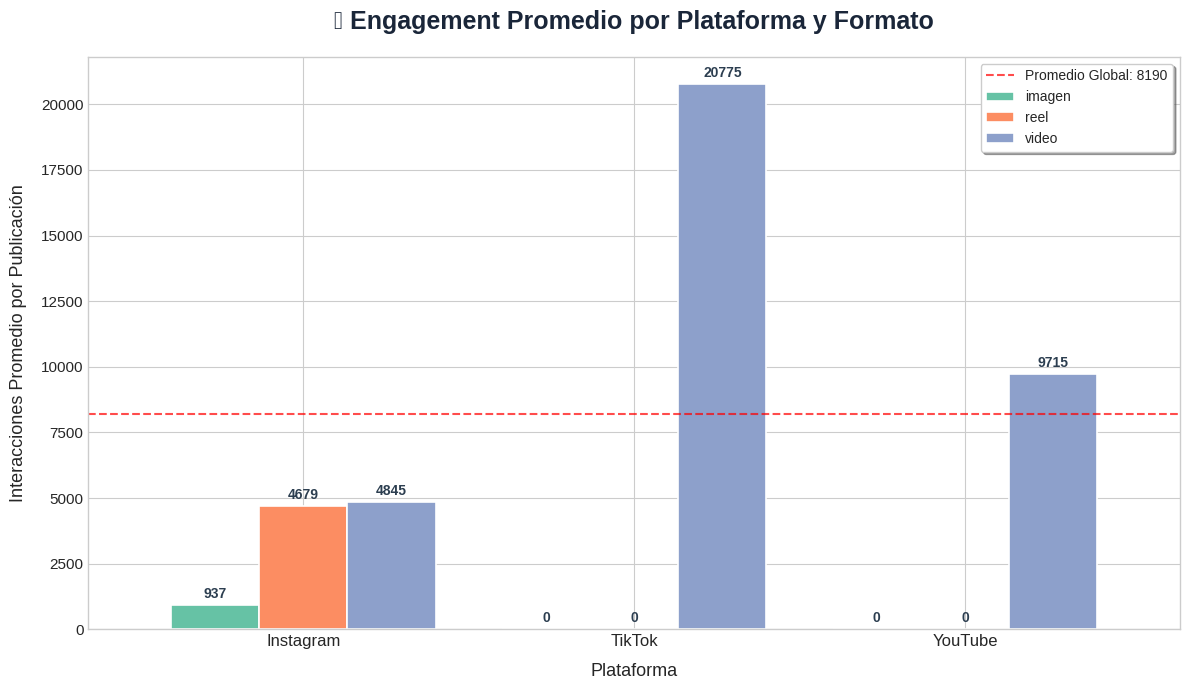

In [10]:
# plataforma y formato
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Cargar datos
file_path = '11_rendimiento_plataforma_formato.csv'
if not os.path.exists(file_path):
    print(f"Advertencia: El archivo '{file_path}' no se encontró. Cargando datos de ejemplo desde el enunciado.")
    # Datos de ejemplo de la tabla en el texto de la celda q11
    data = {
        'plataforma': ['TikTok', 'YouTube', 'Instagram', 'Instagram', 'Instagram'],
        'formato': ['video', 'video', 'video', 'reel', 'imagen'],
        'total_publicaciones': [2, 2, 2, 22, 36],
        'engagement_promedio': [20775.0, 9715.0, 4845.0, 4678.6, 936.7]
    }
    df = pd.DataFrame(data)
else:
    df = pd.read_csv(file_path)

# Configurar estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")  # Paleta de colores armoniosa

# Crear gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(12, 7))

# Pivotar para barras agrupadas
pivot = df.pivot(index='plataforma', columns='formato', values='engagement_promedio')

# Graficar barras agrupadas
pivot.plot(kind='bar', ax=ax, width=0.8, edgecolor='white', linewidth=1.2)

# Etiquetas de datos en cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=10, fontweight='bold', padding=3, color='#2c3e50')

# Títulos y etiquetas
ax.set_title('📊 Engagement Promedio por Plataforma y Formato', fontsize=18, fontweight='bold', pad=20, color='#1a2639')
ax.set_xlabel('Plataforma', fontsize=13, labelpad=10)
ax.set_ylabel('Interacciones Promedio por Publicación', fontsize=13, labelpad=10)
ax.legend(title='Formato', fontsize=11, title_fontsize=12, frameon=True, shadow=True)
ax.tick_params(axis='x', rotation=0, labelsize=12)
ax.tick_params(axis='y', labelsize=11)

# Añadir línea de promedio global (opcional)
avg_global = df['engagement_promedio'].mean()
ax.axhline(y=avg_global, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Promedio Global: {avg_global:.0f}')
ax.legend(loc='upper right', frameon=True, shadow=True)

plt.tight_layout()

# Crear el directorio 'screenshots' si no existe
os.makedirs('screenshots', exist_ok=True)

plt.savefig('screenshots/11_rendimiento_plataforma_formato_chart.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Crecimiento de Audiencia – Ganancia de Seguidores Durante la Campaña

**Pregunta de negocio:** ¿Las campañas con la marca ayudan a los influencers a ganar seguidores durante el período de colaboración, y cómo se relaciona ese crecimiento con el rendimiento de la campaña?

**Lógica:**  
- Se registran los **seguidores al inicio de la campaña** y los **seguidores al final de la campaña** para cada influencer.  
- Se calcula la **tasa de crecimiento** con la fórmula:  
  **Tasa de crecimiento = (Seguidores fin – Seguidores inicio) ÷ Seguidores inicio**  
- Se puede correlacionar este crecimiento con el rendimiento de la campaña (engagement, ROI, conversiones) para entender si el aumento de seguidores está vinculado al éxito de la colaboración.

**Tablas involucradas:**  
- `colaboraciones`  
- `seguidores_influencer`  
- `influencers`

📸 **Resultado:**  


| influencer_id | nombre        | campania_id | seguidores_inicio | seguidores_fin | tasa_crecimiento |
|---------------|---------------|-------------|-------------------|----------------|------------------|
| 9             | Elena Muñoz   | 3           | 7000              | 8500           | 0.2143           |
| 9             | Elena Muñoz   | 4           | 7000              | 8500           | 0.2143           |
| 9             | Elena Muñoz   | 15          | 7000              | 8500           | 0.2143           |
| 9             | Elena Muñoz   | 17          | 7000              | 8500           | 0.2143           |
| 9             | Elena Muñoz   | 106         | 7000              | 8500           | 0.2143           |
| 1             | Ana López     | 1           | 10000             | 12000          | 0.2000           |
| 1             | Ana López     | 10          | 10000             | 12000          | 0.2000           |
| 1             | Ana López     | 11          | 10000             | 12000          | 0.2000           |
| 1             | Ana López     | 104         | 10000             | 12000          | 0.2000           |
| 3             | María García  | 1           | 15000             | 18000          | 0.2000           |
| 3             | María García  | 10          | 15000             | 18000          | 0.2000           |
| 3             | María García  | 12          | 15000             | 18000          | 0.2000           |
| 3             | María García  | 101         | 15000             | 18000          | 0.2000           |
| 6             | Diego Rivas   | 2           | 8000              | 9500           | 0.1875           |
| 6             | Diego Rivas   | 5           | 8000              | 9500           | 0.1875           |
| 6             | Diego Rivas   | 14          | 8000              | 9500           | 0.1875           |
| 6             | Diego Rivas   | 16          | 8000              | 9500           | 0.1875           |
| 6             | Diego Rivas   | 109         | 8000              | 9500           | 0.1875           |
| 4             | Javier Torres | 2           | 19500             | 20000          | 0.0256           |
| 4             | Javier Torres | 11          | 19500             | 20000          | 0.0256           |
| 4             | Javier Torres | 12          | 19500             | 20000          | 0.0256           |
| 4             | Javier Torres | 13          | 19500             | 20000          | 0.0256           |
| 4             | Javier Torres | 105         | 19500             | 20000          | 0.0256           |

**Insight de negocio:**  
- **Elena Muñoz** es un perfil confiable y repetible: su crecimiento estable en distintas campañas la convierte en un activo seguro para mantener resultados constantes.  
- **Ana López** y **María García** destacan por su capacidad de generar incrementos significativos de seguidores en una sola campaña, lo que los hace ideales para acciones de alto impacto.  
- **Diego Rivas** presenta crecimiento moderado (18.75%).  
- **Javier Torres** apenas crece (2.56%), lo que sugiere saturación de su audiencia.

🚀 **Conclusión estratégica:**  
Priorizar a Elena Muñoz para consistencia, mantener inversión en Ana López y María García para expansión rápida, y reconsiderar el uso de Javier para objetivos de crecimiento de audiencia.

## 🧠 Conclusión General

El uso de **SQL analítico avanzado** (CTEs, funciones de ventana, rankings, análisis temporal y de frecuencia) permite extraer valor estratégico de los datos operativos de un CRM de influencers.

Cada una de las 12 consultas entrega **insights accionables** que responden a preguntas de negocio reales:

- **Dónde invertir** para maximizar ROI.
- **A quién elegir** para cada objetivo (eficiencia, alcance, conversión, crecimiento).
- **Cómo ajustar** la estrategia de contenido (frecuencia, formato, plataforma).
- **Cuándo renegociar** o descartar un influencer.

Este repositorio es una demostración práctica de cómo los datos pueden guiar decisiones de marketing con precisión quirúrgica.

---

**📬 Contacto y Contribuciones**

Si deseas utilizar este análisis como base para tu propio CRM de influencers, o tienes sugerencias para ampliarlo, no dudes en abrir un *issue* o *pull request*.
**¡Los datos son el nuevo petróleo, y el SQL es la refinería!**